In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mimg
%matplotlib inline
#plt.rcParams["figure.figsize"] = (20,10)
from PIL import Image
from scipy import misc

import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from keras.models import Sequential, load_model
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.preprocessing import sequence
#from keras.layers import Embedding
from keras.models import Sequential, load_model
#from keras.layers import Convolution1D, Dense, Activation, Dropout, Flatten, MaxPooling1D, Lambda
from keras.utils import np_utils
#from keras import backend as K
from keras.utils.np_utils import to_categorical

import h5py
from keras import callbacks
#from keras.layers import SimpleRNN
from keras.layers import LSTM, Bidirectional
from keras.callbacks import CSVLogger
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

In [3]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import label_binarize

dataset = pd.read_csv('H:/best features/multi/C.csv', low_memory=False)

X = dataset.iloc[:,0:23]
Y = dataset.iloc[:,23]

lb = LabelBinarizer()
lb_results = lb.fit_transform(Y)
y = pd.DataFrame(lb_results, columns=lb.classes_)
y = label_binarize(y, classes=lb.classes_)
                   #classes=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
n_classes = y.shape[1]

In [4]:
y.shape[1]

15

In [5]:
n_classes

15

In [6]:
lb.classes_

array(['BENIGN', 'Bot', 'DDoS', 'DoS Goldeneye', 'DoS Hulk',
       'DoS Slowhttptest', 'DoS Slowloris', 'FTP-Patator', 'Heartbleed',
       'Infiltration', 'PortScan', 'SSH-Patator',
       'Web Attack Brute Force', 'Web Attack Sql Injection',
       'Web Attack XSS'], dtype='<U24')

In [7]:
#X = np.expand_dims(X, axis=2)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
train_ratio = 0.60
validation_ratio = 0.20
test_ratio = 0.20

# train is now 75% of the entire data set
# the _junk suffix means that we drop that variable completely
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio, random_state = 42)

# test is now 10% of the initial data set
# validation is now 15% of the initial data set
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state = 42) 

print(X_train, 
      X_val, 
      X_test)

                a         b         c         d         e         f         g  \
525966   0.000495  0.000003  0.009497  0.062865  0.000000  0.000495  0.000000   
610481   0.006080  0.000011  0.008339  0.085548  0.000000  0.001216  0.003651   
560136   0.000001  0.000000  0.000000  0.000000  0.000000  0.000001  0.000000   
608108   0.000000  0.000000  0.001390  0.003889  0.000000  0.000000  0.000000   
196727   0.000001  0.000251  0.005948  0.015753  0.000000  0.000000  0.000001   
...           ...       ...       ...       ...       ...       ...       ...   
259178   0.000445  0.000207  0.014064  0.113014  0.000000  0.000544  0.000000   
1414414  0.829818  0.000303  0.011421  0.000000  0.609846  0.082982  0.371462   
131932   0.004216  0.000142  0.002241  0.000000  0.269363  0.000675  0.002615   
671155   0.000002  0.000009  0.012740  0.056384  0.000000  0.000001  0.000001   
121958   0.745638  0.000306  0.001810  0.000000  0.214504  0.064325  0.349711   

                h         i

In [8]:
print(y_train, y_val, y_test)

[[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]] [[0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]] [[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]]


In [9]:
X_train = np.expand_dims(X_train, axis=2)
X_val = np.expand_dims(X_val, axis=2)
X_test = np.expand_dims(X_test, axis=2)

In [10]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

In [77]:
#from keras.layers import Flatten
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(None, 23)))
model.add(Dropout(0.1))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.1))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.1))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.1))
model.add(Dense(n_classes))
model.add(Activation('softmax'))

In [78]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional_13 (Bidirectio (None, None, 256)         155648    
_________________________________________________________________
dropout_13 (Dropout)         (None, None, 256)         0         
_________________________________________________________________
bidirectional_14 (Bidirectio (None, None, 256)         394240    
_________________________________________________________________
dropout_14 (Dropout)         (None, None, 256)         0         
_________________________________________________________________
bidirectional_15 (Bidirectio (None, None, 256)         394240    
_________________________________________________________________
dropout_15 (Dropout)         (None, None, 256)         0         
_________________________________________________________________
lstm_16 (LSTM)               (None, 128)              

In [79]:
model.compile(loss="categorical_crossentropy", optimizer="adam",metrics=['accuracy'])

In [100]:
checkpointer = callbacks.ModelCheckpoint(filepath="H:/best features/results/multi results/checkpoint-{epoch:02d}.hdf5", verbose=1, save_best_only=True, monitor='val_acc',mode='max')
csv_logger = CSVLogger('H:/best features/results/multi results/birnnlstmtrainanalysis.csv',separator=',', append=False)
model.fit(X_train, y_train, batch_size = 1000, epochs=28, validation_data=(X_val, y_val),callbacks=[checkpointer,csv_logger])
#cnn.fit(X_train, y_train, nb_epoch=1000, show_accuracy=True,validation_data=(X_test, y_test),callbacks=[checkpointer,csv_logger])
model.save("H:/best features/results/multi results/birnnlstm_model.hdf5")

Train on 1101341 samples, validate on 367114 samples
Epoch 1/28
1101341/1101341 [==============================] - 345s 314us/step - loss: 0.0152 - accuracy: 0.9945 - val_loss: 0.0124 - val_accuracy: 0.9952
Epoch 2/28
1101341/1101341 [==============================] - 347s 315us/step - loss: 0.0151 - accuracy: 0.9945 - val_loss: 0.0127 - val_accuracy: 0.9954
Epoch 3/28
1101341/1101341 [==============================] - 347s 315us/step - loss: 0.0149 - accuracy: 0.9945 - val_loss: 0.0133 - val_accuracy: 0.9951
Epoch 4/28
1101341/1101341 [==============================] - 346s 314us/step - loss: 0.0146 - accuracy: 0.9947 - val_loss: 0.0147 - val_accuracy: 0.9952
Epoch 5/28
1101341/1101341 [==============================] - 346s 315us/step - loss: 0.0149 - accuracy: 0.9945 - val_loss: 0.0133 - val_accuracy: 0.9952
Epoch 6/28
1101341/1101341 [==============================] - 349s 317us/step - loss: 0.0143 - accuracy: 0.9948 - val_loss: 0.0125 - val_accuracy: 0.9958
Epoch 7/28
1101341/1101

In [101]:
score = model.evaluate(X_test, y_test)
print('For Test')
print('Loss: %.4f' % score[0])
print('Accuracy: %.2f' % (score[1]*100))

367114/367114 [==============================] - 44s 120us/step
For Test
Loss: 0.0116
Accuracy: 99.58


In [102]:
pred1 = model.predict(X_test)
# predict classes for test set
prediction_y_classes = model.predict_classes(X_test)

In [103]:
pred1[:12]

array([[9.96173322e-01, 8.40533248e-05, 1.43964444e-05, 1.44190679e-04,
        1.05129293e-04, 5.77999435e-06, 3.19582505e-05, 1.06646086e-03,
        5.75950487e-09, 3.53057840e-06, 4.94201267e-05, 2.31031934e-03,
        3.92602942e-06, 2.27667783e-06, 5.31546493e-06],
       [9.99999762e-01, 9.32191426e-08, 4.96175678e-09, 1.28517266e-10,
        2.03743933e-09, 1.56871124e-07, 1.94820271e-09, 1.83427492e-11,
        3.35383728e-16, 6.82753809e-09, 7.40927875e-11, 2.67957739e-10,
        2.79862696e-11, 1.85096498e-15, 1.66497285e-12],
       [9.99999642e-01, 4.47111610e-08, 1.15481624e-08, 8.09801026e-09,
        1.93109573e-09, 2.75939300e-07, 6.33530135e-08, 1.44182095e-12,
        3.47043825e-16, 2.71573963e-09, 8.36624725e-09, 5.42056604e-08,
        1.14599219e-10, 1.00944112e-12, 5.75415132e-11],
       [9.99086380e-01, 7.91404187e-09, 1.15471278e-06, 4.00158839e-08,
        2.90077820e-04, 8.24369977e-07, 6.04923873e-04, 8.18018634e-07,
        6.49350886e-12, 6.89829136e-0

In [104]:
prediction_y_classes[:12]

array([0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4], dtype=int64)

In [105]:
y_test[:12]

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)

In [106]:
y2 = np.argmax(y_test, axis=1)

In [107]:
y2[:12]

array([0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4], dtype=int64)

In [108]:
conf = confusion_matrix(y2.astype(int), prediction_y_classes.astype(int))

In [109]:
conf

array([[299473,      2,     14,     16,    342,     44,     14,      6,
             0,      0,      3,      0,     18,      0,      0],
       [   147,    152,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0],
       [    27,      0,  25690,      0,      1,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0],
       [    25,      0,      0,   1981,      0,      2,      0,      0,
             0,      0,      0,      0,      0,      0,      0],
       [   595,      0,      0,      1,  33862,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0],
       [     9,      0,      0,      1,      0,   1052,      5,      0,
             0,      0,      0,      0,      0,      0,      0],
       [     7,      0,      0,      1,      0,      6,   1023,      1,
             0,      0,      0,      0,      0,      0,      0],
       [    12,      0,      0,      0,  

In [111]:
print(classification_report(y2.astype(int), prediction_y_classes.astype(int)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    299932
           1       0.99      0.51      0.67       299
           2       1.00      1.00      1.00     25718
           3       0.99      0.99      0.99      2008
           4       0.99      0.98      0.99     34458
           5       0.95      0.99      0.97      1067
           6       0.98      0.99      0.98      1038
           7       0.99      0.99      0.99      1173
           8       1.00      1.00      1.00         2
           9       1.00      0.33      0.50         9
          10       0.99      0.88      0.93       400
          11       1.00      0.93      0.96       629
          12       0.62      0.91      0.74       250
          13       0.00      0.00      0.00         4
          14       1.00      0.01      0.02       127

    accuracy                           1.00    367114
   macro avg       0.90      0.77      0.78    367114
weighted avg       1.00   

In [112]:
#function to draw confusion matrix
def draw_confusion_matrix(true,preds):
    conf_matx = confusion_matrix(true, preds)
    sns.heatmap(conf_matx, annot=True,annot_kws={"size": 20},fmt='g', cbar=False, cmap="viridis")
    plt.show()
    #return conf_matx

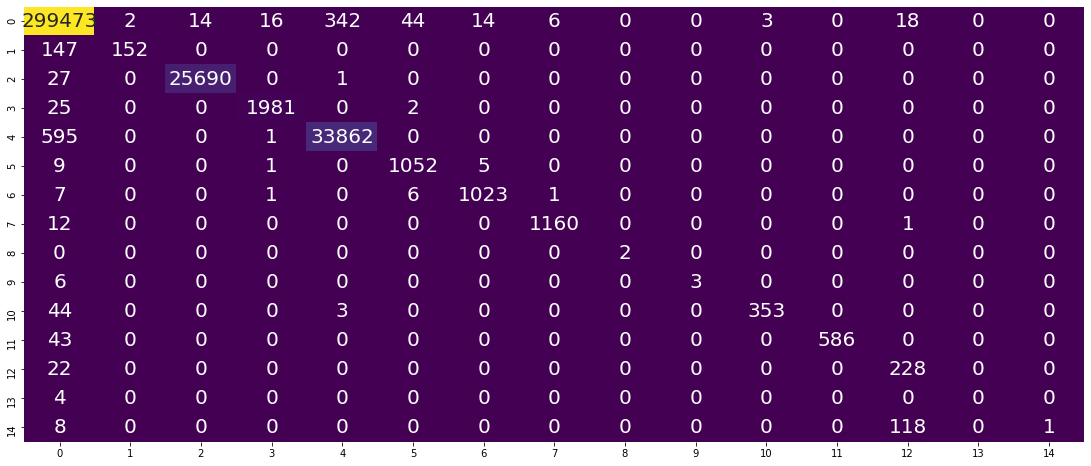

In [113]:
plt.rcParams["figure.figsize"] = (19,8)
draw_confusion_matrix(y2.astype(int), prediction_y_classes.astype(int))

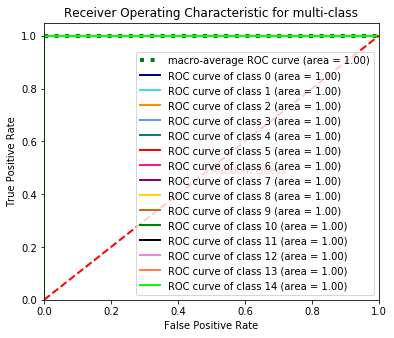

In [114]:
#pred1=model.predict(X_test)
#t1=sum(x==0 for x in pred1-y_test)/len(pred1)

#from scipy import interp
from numpy import interp
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.metrics import roc_curve, auc

### MACRO
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[i], pred1[i])
    roc_auc[i] = auc(fpr[i], tpr[i])


all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

lw=2
plt.figure(figsize=(6,5.1))
plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='green', linestyle=':', linewidth=4)

colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal', 'red', 'deeppink', 'purple', 'gold', 'chocolate', 'green', 'black', 'violet', 'coral', 'lime'])
    #'aqua', 'darkorange', 'cornflowerblue'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--',color='red', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.annotate('Random Guess',(.5,.48),color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for multi-class')
plt.legend(loc="lower right")
plt.show()

In [115]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# For each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i],
                                                        pred1[:, i])
    average_precision[i] = average_precision_score(y_test[:, i], pred1[:, i])

# A "micro-average": quantifying score on all classes jointly
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(),
    pred1.ravel())
average_precision["micro"] = average_precision_score(y_test, pred1,
                                                     average="micro")
print('Average precision score, micro-averaged over all classes: {0:0.2f}'
      .format(average_precision["micro"]))

Average precision score, micro-averaged over all classes: 1.00


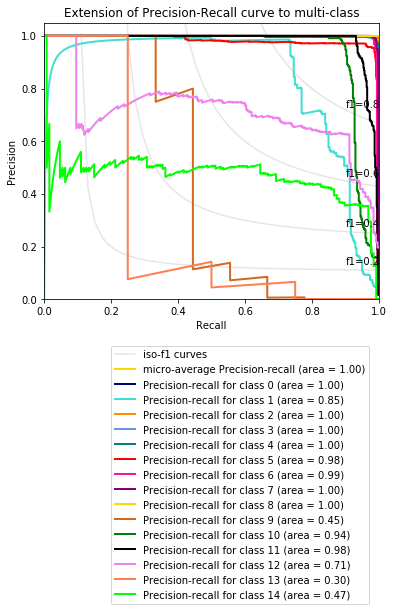

In [116]:
from itertools import cycle
# setup plot details
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal', 'red', 'deeppink', 'purple', 'gold', 'chocolate', 'green', 'black', 'violet', 'coral', 'lime'])

plt.figure(figsize=(6, 6.1))
f_scores = np.linspace(0.2, 0.8, num=4)
lines = []
labels = []
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = f_score * x / (2 * x - f_score)
    l, = plt.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.2)
    plt.annotate('f1={0:0.1f}'.format(f_score), xy=(0.9, y[45] + 0.02))

lines.append(l)
labels.append('iso-f1 curves')
l, = plt.plot(recall["micro"], precision["micro"], color='gold', lw=2)
lines.append(l)
labels.append('micro-average Precision-recall (area = {0:0.2f})'
              ''.format(average_precision["micro"]))

for i, color in zip(range(n_classes), colors):
    l, = plt.plot(recall[i], precision[i], color=color, lw=2)
    lines.append(l)
    labels.append('Precision-recall for class {0} (area = {1:0.2f})'
                  ''.format(i, average_precision[i]))

fig = plt.gcf()
fig.subplots_adjust(bottom=0.25)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Extension of Precision-Recall curve to multi-class')
plt.legend(lines, labels, loc=(.2, -1.1), prop=dict(size=10))


plt.show()